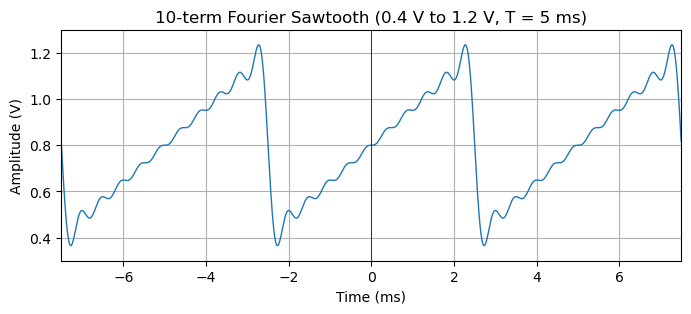

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 5e-3           # period (s)
Vmin = 0.4         # minimum value
Vmax = 1.2         # maximum value
offset = (Vmax + Vmin) / 2.0    # DC offset
amplitude = (Vmax - Vmin) / 2.0 # half of the peak-to-peak amplitude
N = 10              # number of Fourier terms

# Fourier coefficients for a unit-amplitude sawtooth (range -1..1)
coeffs = [
    0.6366197723675814,
   -0.3183098861837907,
    0.2122065907891938,
   -0.15915494309189535,
    0.12732395447351627,
   -0.1061032953945969,
    0.09094568176679733,
   -0.07957747154594767,
    0.0707355302630646,
   -0.06366197723675814
]

def sawtooth_approx(t, T=T, amplitude=amplitude, offset=offset, coeffs=coeffs):
    """Return N-term Fourier approximation of a sawtooth wave with period T."""
    t = np.asarray(t)
    s = np.zeros_like(t, dtype=float)
    for n, a in enumerate(coeffs, start=1):
        s += a * np.sin(2.0 * np.pi * n * t / T)
    return offset + amplitude * s  # scale and shift to desired range

# Example: sample and plot one period
fs = 200000  # sampling frequency 200 kHz
t = np.arange(-1.5*T, 1.5*T, 1.0/fs)
y = sawtooth_approx(t)

plt.figure(figsize=(8,3))
plt.plot(t*1e3, y, linewidth=1)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (V)')
plt.title('10-term Fourier Sawtooth (0.4 V to 1.2 V, T = 5 ms)')
plt.grid(True)
plt.xlim(-1.5*T*1e3, 1.5*T*1e3)
plt.ylim(0.3, 1.3)
plt.show()